In [2]:
import os
DATASET_PATH = "/kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed"

patients = sorted(os.listdir(DATASET_PATH))

print("Nombre de patients :", len(patients))
print(patients[:5])
patient = patients[0]

print(os.listdir(os.path.join(DATASET_PATH, patient)))

Nombre de patients : 240
['sub-strokecase0001', 'sub-strokecase0002', 'sub-strokecase0003', 'sub-strokecase0004', 'sub-strokecase0006']
['flair.npy', 'adc.npy', 'dwi.npy', 'mask.npy']


In [3]:
import numpy as np
import os

DATASET_PATH = "/kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed"

patient = "sub-strokecase0001"
patient_path = os.path.join(DATASET_PATH, patient)

for file in ["flair.npy", "adc.npy", "dwi.npy", "mask.npy"]:
    data = np.load(os.path.join(patient_path, file))
    print(f"{file}")
    print(f"Shape : {data.shape}")
    print(f"Dtype : {data.dtype}")
    print("-" * 40)

flair.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
adc.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
dwi.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
mask.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------


### Import Libraries

In [4]:
!pip install -q monai nibabel SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.6 MB/s eta 0:00:0000:01


In [5]:
# installation mlflow
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 95.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 96.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 14.0 MB/s eta 0:00:00


In [6]:
import os
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric, MeanIoU
from monai.transforms import Compose, Activations, AsDiscrete, RandFlipd, RandRotate90d
from monai.data import decollate_batch

In [7]:
MLFLOW_TRACKING_URI = "https://elated-autistic-subfloor.ngrok-free.dev"
EXPERIMENT_NAME = "Stroke-Segmentation"

In [8]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

try:
    client = mlflow.MlflowClient()
    client.search_experiments()  # ping simple pour tester la connexion
    print(f"Connexion réussie au serveur MLflow : {MLFLOW_TRACKING_URI}")
except Exception as e:
    print(f"Impossible de se connecter au serveur MLflow ({MLFLOW_TRACKING_URI})")
    print(f"Erreur : {e}")

mlflow.set_experiment(EXPERIMENT_NAME)
print(f"Experiment actif : {EXPERIMENT_NAME}")

Connexion réussie au serveur MLflow : https://elated-autistic-subfloor.ngrok-free.dev
Experiment actif : Stroke-Segmentation


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 50)
print(f"PyTorch Version : {torch.__version__}")
print(f"MONAI Version   : {__import__('monai').__version__}")
print(f"Device          : {device}")
print("=" * 50)

PyTorch Version : 2.10.0+cu128
MONAI Version   : 1.6.0
Device          : cuda


### configuration

In [10]:
from pathlib import Path
import random
import numpy as np
import torch
DATASET_PATH = Path("/kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed")
BATCH_SIZE = 16
NUM_EPOCHS = 50
NUM_WORKERS = 2
MODALITY = "dwi"
NUM_CHANNELS = 1
experiments = [
    {"name": "DWI_2D_Adam_lr1e3", "optimizer": Adam, "lr": 1e-3},
    {"name": "DWI_2D_Adam_lr5e4_DWI", "optimizer": Adam, "lr": 5e-4}
]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = Path("/kaggle/working/models/unet2d_dwi")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("U-Net 2D DWI - Project Configuration")
print(f"Dataset Path : {DATASET_PATH}")
print(f"Modality     : {MODALITY.upper()}")
print(f"Channels     : {NUM_CHANNELS}")
print(f"Device       : {DEVICE}")
print(f"Batch Size   : {BATCH_SIZE}")
print(f"Epochs       : {NUM_EPOCHS}")
print(f"Workers      : {NUM_WORKERS}")
print(f"Experiments  : {len(experiments)}")
print(f"Save Dir     : {SAVE_DIR}")
for exp in experiments:
    print(f"{exp['name']} | LR = {exp['lr']}")

U-Net 2D DWI - Project Configuration
Dataset Path : /kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed
Modality     : DWI
Channels     : 1
Device       : cuda
Batch Size   : 16
Epochs       : 50
Workers      : 2
Experiments  : 2
Save Dir     : /kaggle/working/models/unet2d_dwi
DWI_2D_Adam_lr1e3 | LR = 0.001
DWI_2D_Adam_lr5e4_DWI | LR = 0.0005


### Train / Validation / Test Split

In [11]:
# Get all patient folders
patients = sorted(
    [
        patient.name
        for patient in DATASET_PATH.iterdir()
        if patient.is_dir()
    ]
)

print(f"Total Patients : {len(patients)}")


train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

# Convert patient names to full paths

train_patients = [
    DATASET_PATH / p
    for p in train_patients
]

val_patients = [
    DATASET_PATH / p
    for p in val_patients
]

test_patients = [
    DATASET_PATH / p
    for p in test_patients
]


print("\nDataset Split")
print("-" * 40)

print(
    f"Train      : {len(train_patients):3d} patients "
    f"({len(train_patients)/len(patients)*100:.1f}%)"
)

print(
    f"Validation : {len(val_patients):3d} patients "
    f"({len(val_patients)/len(patients)*100:.1f}%)"
)

print(
    f"Test       : {len(test_patients):3d} patients "
    f"({len(test_patients)/len(patients)*100:.1f}%)"
)

Total Patients : 240

Dataset Split
----------------------------------------
Train      : 168 patients (70.0%)
Validation :  36 patients (15.0%)
Test       :  36 patients (15.0%)


### Data Augmentation / Transforms

In [12]:
train_transform = Compose([

    # Random horizontal flip
    RandFlipd(
        keys=["image", "mask"],
        prob=0.5,
        spatial_axis=0
    ),

    # Random vertical flip
    RandFlipd(
        keys=["image", "mask"],
        prob=0.5,
        spatial_axis=1
    ),

    # Random 90-degree rotation
    RandRotate90d(
        keys=["image", "mask"],
        prob=0.5,
        max_k=3
    )
])

print("Training data augmentation configured.")

Training data augmentation configured.


### Création du StrokeDataset

In [13]:
class StrokeDataset2D(Dataset):

    def __init__(self, patient_dirs, transform=None):

        self.samples = []
        self.transform = transform

        # Build the list of all 2D slices

        for patient_dir in patient_dirs:

            # Load DWI only to determine the number of slices
            dwi = np.load(
                patient_dir / "dwi.npy",
                mmap_mode="r"
            )

            num_slices = dwi.shape[-1]

            for slice_idx in range(num_slices):

                self.samples.append(
                    (patient_dir, slice_idx)
                )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, index):

        patient_dir, slice_idx = self.samples[index]

        # Load DWI volume and Ground Truth mask

        dwi = np.load(
            patient_dir / "dwi.npy",
            mmap_mode="r"
        ).astype(np.float32)

        mask = np.load(
            patient_dir / "mask.npy",
            mmap_mode="r"
        ).astype(np.float32)

        # Extract 2D slice

        image = dwi[:, :, slice_idx]
        target = mask[:, :, slice_idx]

        # Z-score Normalization

        mean = image.mean()
        std = image.std()

        if std > 0:
            image = (image - mean) / std

        image = np.expand_dims(
            image,
            axis=0
        )

        target = np.expand_dims(
            target,
            axis=0
        )

        # Convert to PyTorch tensors

        image = torch.from_numpy(image).float()
        target = torch.from_numpy(target).float()

        if self.transform is not None:

            data = {
                "image": image,
                "mask": target
            }

            data = self.transform(data)

            image = data["image"]
            target = data["mask"]

        return image, target

### Create Datasets and DataLoaders - DWI

In [14]:
# Create Datasets

# Training dataset WITH data augmentation
train_dataset = StrokeDataset2D(
    train_patients,
    transform=train_transform
)

# Validation dataset WITHOUT data augmentation
val_dataset = StrokeDataset2D(
    val_patients,
    transform=None
)

# Test dataset WITHOUT data augmentation
test_dataset = StrokeDataset2D(
    test_patients,
    transform=None
)

# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


print("=" * 60)
print("Dataset Statistics - DWI")
print("=" * 60)

print(f"Training slices   : {len(train_dataset)}")
print(f"Validation slices : {len(val_dataset)}")
print(f"Test slices       : {len(test_dataset)}")

print()

print(f"Train batches      : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Test batches       : {len(test_loader)}")

print("=" * 60)


images, masks = next(iter(train_loader))

print("\nBatch Verification")
print("-" * 40)

print(f"Input shape : {images.shape}")
print(f"Mask shape  : {masks.shape}")

Dataset Statistics - DWI
Training slices   : 10752
Validation slices : 2304
Test slices       : 2304

Train batches      : 672
Validation batches : 144
Test batches       : 144

Batch Verification
----------------------------------------
Input shape : torch.Size([16, 1, 128, 128])
Mask shape  : torch.Size([16, 1, 128, 128])


### Définir la Loss et l'Optimizer

In [15]:
# Loss Function

loss_function = DiceCELoss(
    sigmoid=True,
    squared_pred=True,
    reduction="mean",
    lambda_ce=0.5,
    lambda_dice=1.5
)

# Evaluation Metrics

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

iou_metric = MeanIoU(
    include_background=False,
    reduction="mean"
)

# Display Configuration

print("=" * 60)
print("Loss Function and Evaluation Metrics - DWI")
print("=" * 60)

print("\nLoss Function")
print(loss_function)

print("\nEvaluation Metrics")
print("- Dice Score")
print("- Mean IoU")

print("\nExperiments")

for exp in experiments:
    print(
        f"{exp['name']} | LR = {exp['lr']}"
    )

print("=" * 60)

Loss Function and Evaluation Metrics - DWI

Loss Function
DiceCELoss(
  (dice): DiceLoss()
  (cross_entropy): CrossEntropyLoss()
  (binary_cross_entropy): BCEWithLogitsLoss()
)

Evaluation Metrics
- Dice Score
- Mean IoU

Experiments
DWI_2D_Adam_lr1e3 | LR = 0.001
DWI_2D_Adam_lr5e4_DWI | LR = 0.0005


In [16]:
# Post-processing for predictions

post_pred = Compose([
    Activations(sigmoid=True),
    AsDiscrete(threshold=0.5)
])

### Fonction d'entraînement

In [17]:
def train_one_epoch(
    model,
    train_loader,
    optimizer,
    loss_function,
    device
):

    # Set model to training mode
    model.train()

    # Initialize cumulative loss
    epoch_loss = 0.0

    # Iterate over training batches
    for images, masks in train_loader:

        # Move data to device
        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = loss_function(
            outputs,
            masks
        )

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate batch loss
        epoch_loss += loss.item()

    # Average loss over all training batches
    epoch_loss /= len(train_loader)

    return epoch_loss

### Fonction de validation

In [18]:
from monai.metrics import MeanIoU

def validate(model, val_loader, dice_metric, iou_metric, post_pred, device):

    # Set the model to evaluation mode
    model.eval()

    # Reset metrics before validation
    dice_metric.reset()
    iou_metric.reset()

    # Disable gradient computation to save memory and speed up inference
    with torch.no_grad():

        # Iterate over the validation dataset
        for images, masks in val_loader:

            # Move data to the selected device
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            outputs = model(images)

            # Apply post-processing:
            # 1. Sigmoid activation
            # 2. Threshold at 0.5 to obtain binary masks
            outputs = [
                post_pred(pred)
                for pred in decollate_batch(outputs)
            ]

            # Convert batch of masks into a list
            masks = decollate_batch(masks)

            # Update Dice metric
            dice_metric(
                y_pred=outputs,
                y=masks
            )

            # Update IoU metric
            iou_metric(
                y_pred=outputs,
                y=masks
            )

    # Compute the final metrics over the entire validation set
    dice = dice_metric.aggregate().item()
    iou = iou_metric.aggregate().item()

    # Reset metrics for the next validation epoch
    dice_metric.reset()
    iou_metric.reset()

    return dice, iou

### U-Net 2D DWI - Training Experiments

In [19]:
import os
os.environ["MLFLOW_HTTP_REQUEST_TIMEOUT"] = "100000"

results = []
DWI_SAVE_DIR = SAVE_DIR / "dwi"
DWI_SAVE_DIR.mkdir(parents=True, exist_ok=True)
for exp in experiments:
    run_name = exp["name"]
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tag("experiment_group", "DWI-2D")
        mlflow.set_tag("modality", "DWI")
        mlflow.set_tag("dimension", "2D")
        mlflow.set_tag("dataset", "ISLES2022")
        mlflow.set_tag("framework", "PyTorch + MONAI")
        mlflow.set_tag("task", "ischemic_stroke_lesion_segmentation")
        mlflow.log_params({
            "architecture": "U-Net",
            "model": "MONAI UNet",
            "spatial_dims": 2,
            "in_channels": NUM_CHANNELS,
            "out_channels": 1,
            "channels": str((16, 32, 64, 128, 256)),
            "strides": str((2, 2, 2, 2)),
            "num_res_units": 2,
            "optimizer": exp["optimizer"].__name__,
            "learning_rate": exp["lr"],
            "batch_size": BATCH_SIZE,
            "epochs": NUM_EPOCHS,
            "num_workers": NUM_WORKERS,
            "scheduler": "CosineAnnealingLR",
            "loss_function": "DiceCELoss",
            "loss_lambda_ce": 0.5,
            "loss_lambda_dice": 1.5,
            "dice_include_background": False,
            "iou_include_background": False,
            "augmentation": "RandFlipd + RandRotate90d",
            "seed": SEED
        })
        print("\n" + "=" * 60)
        print(f"Experiment: {run_name}")
        print(f"MLflow Run ID: {run.info.run_id}")
        print("=" * 60)
        model = UNet(
            spatial_dims=2,
            in_channels=NUM_CHANNELS,
            out_channels=1,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2
        ).to(DEVICE)
        optimizer = exp["optimizer"](
            model.parameters(),
            lr=exp["lr"]
        )
        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=NUM_EPOCHS
        )
        best_dice = 0.0
        best_iou = 0.0
        best_epoch = 0
        train_losses = []
        val_dices = []
        val_ious = []
        model_path = DWI_SAVE_DIR / f"best_model_{exp['name']}.pth"
        for epoch in range(NUM_EPOCHS):
            epoch_loss = train_one_epoch(
                model=model,
                train_loader=train_loader,
                optimizer=optimizer,
                loss_function=loss_function,
                device=DEVICE
            )
            train_losses.append(epoch_loss)
            dice, iou = validate(
                model=model,
                val_loader=val_loader,
                dice_metric=dice_metric,
                iou_metric=iou_metric,
                post_pred=post_pred,
                device=DEVICE
            )
            val_dices.append(dice)
            val_ious.append(iou)
            scheduler.step()
            mlflow.log_metric("train_loss", epoch_loss, step=epoch + 1)
            mlflow.log_metric("val_dice", dice, step=epoch + 1)
            mlflow.log_metric("val_iou", iou, step=epoch + 1)
            if dice > best_dice:
                best_dice = dice
                best_iou = iou
                best_epoch = epoch + 1
                torch.save(model.state_dict(), model_path)
            print(
                f"Epoch [{epoch + 1:03d}/{NUM_EPOCHS}] "
                f"| Loss: {epoch_loss:.4f} "
                f"| Dice: {dice:.4f} "
                f"| IoU: {iou:.4f}"
            )
        mlflow.log_metric("best_dice", best_dice)
        mlflow.log_metric("best_iou", best_iou)
        mlflow.log_metric("best_epoch", best_epoch)
        try:
            mlflow.log_artifact(str(model_path), artifact_path="model")
            print(f"Model artifact uploaded successfully: {model_path.name}")
        except Exception as e:
            print(f"WARNING: Model artifact upload failed: {e}")
        curve_dir = SAVE_DIR / "mlflow_curves"
        curve_dir.mkdir(parents=True, exist_ok=True)
        curve_path = curve_dir / f"training_curves_{exp['name']}.png"
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        epochs = range(1, NUM_EPOCHS + 1)
        axes[0].plot(epochs, train_losses)
        axes[0].set_title("Training Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].grid(True)
        axes[1].plot(epochs, val_dices)
        axes[1].set_title("Validation Dice")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Dice")
        axes[1].set_ylim(0, 1)
        axes[1].grid(True)
        axes[2].plot(epochs, val_ious)
        axes[2].set_title("Validation IoU")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("IoU")
        axes[2].set_ylim(0, 1)
        axes[2].grid(True)
        plt.tight_layout()
        plt.savefig(curve_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        try:
            mlflow.log_artifact(str(curve_path), artifact_path="plots")
            print(f"Training curves uploaded successfully: {curve_path.name}")
        except Exception as e:
            print(f"WARNING: Training curves upload failed: {e}")
        run_id = run.info.run_id
        results.append({
            "Experiment": run_name,
            "Run Name": run_name,
            "MLflow Run ID": run_id,
            "Learning Rate": exp["lr"],
            "Best Dice": best_dice,
            "Best IoU": best_iou,
            "Best Epoch": best_epoch,
            "Train Loss": train_losses,
            "Validation Dice": val_dices,
            "Validation IoU": val_ious,
            "Model Path": str(model_path)
        })
        print(
            f"[FIN] {run_name} | Best Dice: {best_dice:.4f} | "
            f"Best IoU: {best_iou:.4f} | Best Epoch: {best_epoch} | "
            f"MLflow Run ID: {run_id}"
        )
print("\nDWI training completed successfully.")


Experiment: DWI_2D_Adam_lr1e3
MLflow Run ID: ee6790f42c1a4cb98eaf0fb7b6cba28a
Epoch [001/50] | Loss: 1.7295 | Dice: 0.4351 | IoU: 0.3237
Epoch [002/50] | Loss: 1.4329 | Dice: 0.5410 | IoU: 0.4264
Epoch [003/50] | Loss: 1.2370 | Dice: 0.5840 | IoU: 0.4716
Epoch [004/50] | Loss: 1.2179 | Dice: 0.5954 | IoU: 0.4826
Epoch [005/50] | Loss: 1.2083 | Dice: 0.5936 | IoU: 0.4808
Epoch [006/50] | Loss: 1.2041 | Dice: 0.6254 | IoU: 0.5116
Epoch [007/50] | Loss: 1.1987 | Dice: 0.6090 | IoU: 0.4956
Epoch [008/50] | Loss: 1.1952 | Dice: 0.6234 | IoU: 0.5039
Epoch [009/50] | Loss: 1.1940 | Dice: 0.6342 | IoU: 0.5174
Epoch [010/50] | Loss: 1.1897 | Dice: 0.6337 | IoU: 0.5163
Epoch [011/50] | Loss: 1.1900 | Dice: 0.6290 | IoU: 0.5127
Epoch [012/50] | Loss: 1.1854 | Dice: 0.6296 | IoU: 0.5149
Epoch [013/50] | Loss: 1.1847 | Dice: 0.6387 | IoU: 0.5239
Epoch [014/50] | Loss: 1.1822 | Dice: 0.6275 | IoU: 0.5119
Epoch [015/50] | Loss: 1.1813 | Dice: 0.6409 | IoU: 0.5219
Epoch [016/50] | Loss: 1.1266 | Dice

In [20]:
print(model_path)
print(model_path.exists())
print(f"Model size: {model_path.stat().st_size / (1024 ** 2):.2f} MB")

/kaggle/working/models/unet2d_dwi/dwi/best_model_DWI_2D_Adam_lr5e4_DWI.pth
True
Model size: 6.23 MB


### Tracer les courbes de Loss et du Dice

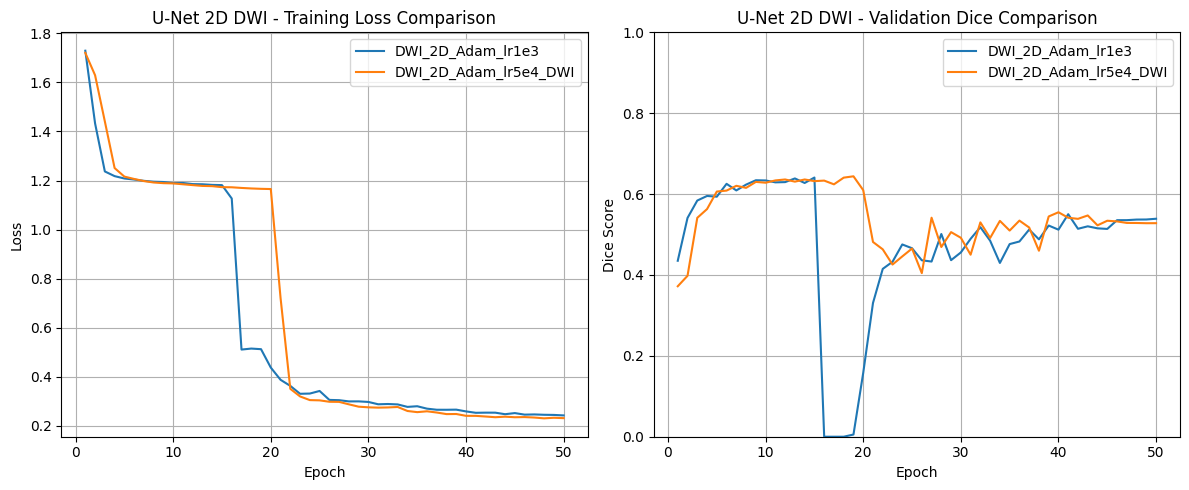

In [21]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for result in results:
    epochs = range(1, len(result["Train Loss"]) + 1)
    plt.plot(epochs, result["Train Loss"], label=result["Experiment"])
plt.title("U-Net 2D DWI - Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
for result in results:
    epochs = range(1, len(result["Validation Dice"]) + 1)
    plt.plot(epochs, result["Validation Dice"], label=result["Experiment"])
plt.title("U-Net 2D DWI - Validation Dice Comparison")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Load the Best DWI Model

In [22]:
best_result = max(results, key=lambda x: x["Best Dice"])
print("Best Experiment :", best_result["Experiment"])
print("Best Dice       :", f"{best_result['Best Dice']:.4f}")
print("Best IoU        :", f"{best_result['Best IoU']:.4f}")
print("Best Epoch      :", best_result["Best Epoch"])
print("Model Path      :", best_result["Model Path"])
print("MLflow Run ID   :", best_result["MLflow Run ID"])
model = UNet(
    spatial_dims=2,
    in_channels=NUM_CHANNELS,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2
).to(DEVICE)
model.load_state_dict(
    torch.load(
        best_result["Model Path"],
        map_location=DEVICE
    )
)
model.eval()
print("Best DWI model loaded successfully.")

Best Experiment : DWI_2D_Adam_lr5e4_DWI
Best Dice       : 0.6440
Best IoU        : 0.5267
Best Epoch      : 19
Model Path      : /kaggle/working/models/unet2d_dwi/dwi/best_model_DWI_2D_Adam_lr5e4_DWI.pth
MLflow Run ID   : 883ef5b4a8674ef18c886dfcac6cb234
Best DWI model loaded successfully.


### Evaluate the Best DWI Model

In [24]:
print(best_result.keys())

dict_keys(['Experiment', 'Run Name', 'MLflow Run ID', 'Learning Rate', 'Best Dice', 'Best IoU', 'Best Epoch', 'Train Loss', 'Validation Dice', 'Validation IoU', 'Model Path'])


In [25]:
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ==========================================================
# FLAIR-3D - Test Set Evaluation
# ==========================================================

model.eval()

dice_metric.reset()
iou_metric.reset()

all_predictions = []
all_masks = []


with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(images)

        predictions = (
            torch.sigmoid(outputs) > 0.5
        ).float()

        # ==================================================
        # Dice
        # ==================================================

        dice_metric(
            y_pred=predictions,
            y=masks
        )

        # ==================================================
        # IoU
        # ==================================================

        iou_metric(
            y_pred=predictions,
            y=masks
        )

        # ==================================================
        # Store predictions and masks
        # ==================================================

        all_predictions.append(
            predictions
            .cpu()
            .numpy()
            .ravel()
        )

        all_masks.append(
            masks
            .cpu()
            .numpy()
            .ravel()
        )


# ==========================================================
# Aggregate Dice / IoU
# ==========================================================

dice = dice_metric.aggregate().item()

iou = iou_metric.aggregate().item()

dice_metric.reset()
iou_metric.reset()


# ==========================================================
# Convert predictions and masks
# ==========================================================

all_predictions = np.concatenate(
    all_predictions
).astype(np.uint8)

all_masks = np.concatenate(
    all_masks
).astype(np.uint8)


# ==========================================================
# Precision / Recall / F1
# ==========================================================

precision = precision_score(
    all_masks,
    all_predictions,
    zero_division=0
)

recall = recall_score(
    all_masks,
    all_predictions,
    zero_division=0
)

f1 = f1_score(
    all_masks,
    all_predictions,
    zero_division=0
)


# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    all_masks,
    all_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ==========================================================
# Evaluation Metrics Table
# ==========================================================

results_metrics = pd.DataFrame({

    "Metric": [
        "Dice",
        "IoU",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Value": [
        dice,
        iou,
        precision,
        recall,
        f1
    ]
})


# ==========================================================
# Log Test Metrics to MLflow
# ==========================================================

with mlflow.start_run(
    run_id=best_result["MLflow Run ID"]
):

    mlflow.log_metric(
        "test_dice",
        dice
    )

    mlflow.log_metric(
        "test_iou",
        iou
    )

    mlflow.log_metric(
        "test_precision",
        precision
    )

    mlflow.log_metric(
        "test_recall",
        recall
    )

    mlflow.log_metric(
        "test_f1",
        f1
    )

    mlflow.set_tag(
        "evaluation_status",
        "test_evaluated"
    )


# ==========================================================
# Display Results
# ==========================================================

print("=" * 60)
print("FLAIR-3D - Test Set Performance")
print("=" * 60)

display(
    results_metrics
)

print("\nConfusion Matrix")
print(cm)

print("\nPixel Classification")

print(
    f"TP : {tp}"
)

print(
    f"TN : {tn}"
)

print(
    f"FP : {fp}"
)

print(
    f"FN : {fn}"
)

🏃 View run DWI_2D_Adam_lr5e4_DWI at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/883ef5b4a8674ef18c886dfcac6cb234
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
FLAIR-3D - Test Set Performance


,Metric,Value
0,Dice,0.662064
1,IoU,0.548137
2,Precision,0.820713
3,Recall,0.751457
4,F1-score,0.784560



Confusion Matrix
[[37452281    41803]
 [   63292   191360]]

Pixel Classification
TP : 191360
TN : 37452281
FP : 41803
FN : 63292


### Evaluation Charts

In [27]:
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ==========================================================
# Evaluation Directory
# ==========================================================

evaluation_dir = SAVE_DIR / "mlflow_evaluation"

evaluation_dir.mkdir(
    parents=True,
    exist_ok=True
)

test_metrics_path = (
    evaluation_dir / "test_metrics.png"
)

confusion_matrix_path = (
    evaluation_dir / "confusion_matrix.png"
)


# ==========================================================
# Test Metrics Plot
# ==========================================================

fig, ax = plt.subplots(
    figsize=(10, 5)
)

bars = ax.bar(
    results_metrics["Metric"],
    results_metrics["Value"]
)

ax.set_ylim(
    0,
    1
)

ax.set_ylabel(
    "Score"
)

ax.set_title(
    "FLAIR-3D Model - Test Metrics"
)

for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        height + 0.02,
        f"{height:.3f}",
        ha="center"
    )

ax.grid(
    axis="y"
)

plt.tight_layout()

plt.savefig(
    test_metrics_path,
    dpi=150,
    bbox_inches="tight"
)

plt.close(fig)


# ==========================================================
# Confusion Matrix
# ==========================================================

fig, ax = plt.subplots(
    figsize=(6, 6)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Background",
        "Stroke"
    ]
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

ax.set_title(
    "Confusion Matrix - FLAIR-3D Model"
)

plt.tight_layout()

plt.savefig(
    confusion_matrix_path,
    dpi=150,
    bbox_inches="tight"
)

plt.close(fig)


# ==========================================================
# Log Artifacts to MLflow
# ==========================================================

with mlflow.start_run(
    run_id=best_result["MLflow Run ID"]
):

    mlflow.log_artifact(
        str(test_metrics_path),
        artifact_path="evaluation"
    )

    mlflow.log_artifact(
        str(confusion_matrix_path),
        artifact_path="evaluation"
    )


print(
    "Evaluation artifacts saved and logged "
    "to the Best FLAIR-3D Run."
)

🏃 View run DWI_2D_Adam_lr5e4_DWI at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/883ef5b4a8674ef18c886dfcac6cb234
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
Evaluation artifacts saved and logged to the Best FLAIR-3D Run.


### Confusion Matrix

Confusion Matrix
[[37452281    41803]
 [   63292   191360]]

True Negatives : 37452281
False Positives: 41803
False Negatives: 63292
True Positives : 191360


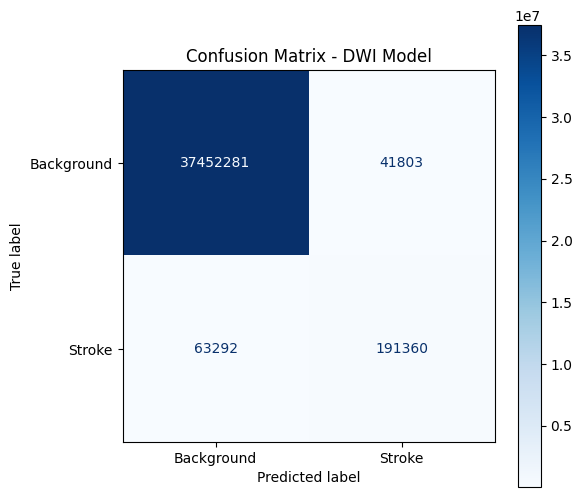

In [28]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)

        predictions = (torch.sigmoid(outputs) > 0.5).float()

        all_predictions.extend(
            predictions.cpu().numpy().flatten().astype(np.uint8)
        )

        all_targets.extend(
            masks.cpu().numpy().flatten().astype(np.uint8)
        )

# Compute confusion matrix
cm = confusion_matrix(
    all_targets,
    all_predictions
)

tn, fp, fn, tp = cm.ravel()

print("=" * 50)
print("Confusion Matrix")
print("=" * 50)

print(cm)

print(f"\nTrue Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Background", "Stroke"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title("Confusion Matrix - DWI Model")

plt.show()

### Visualize DWI Segmentation

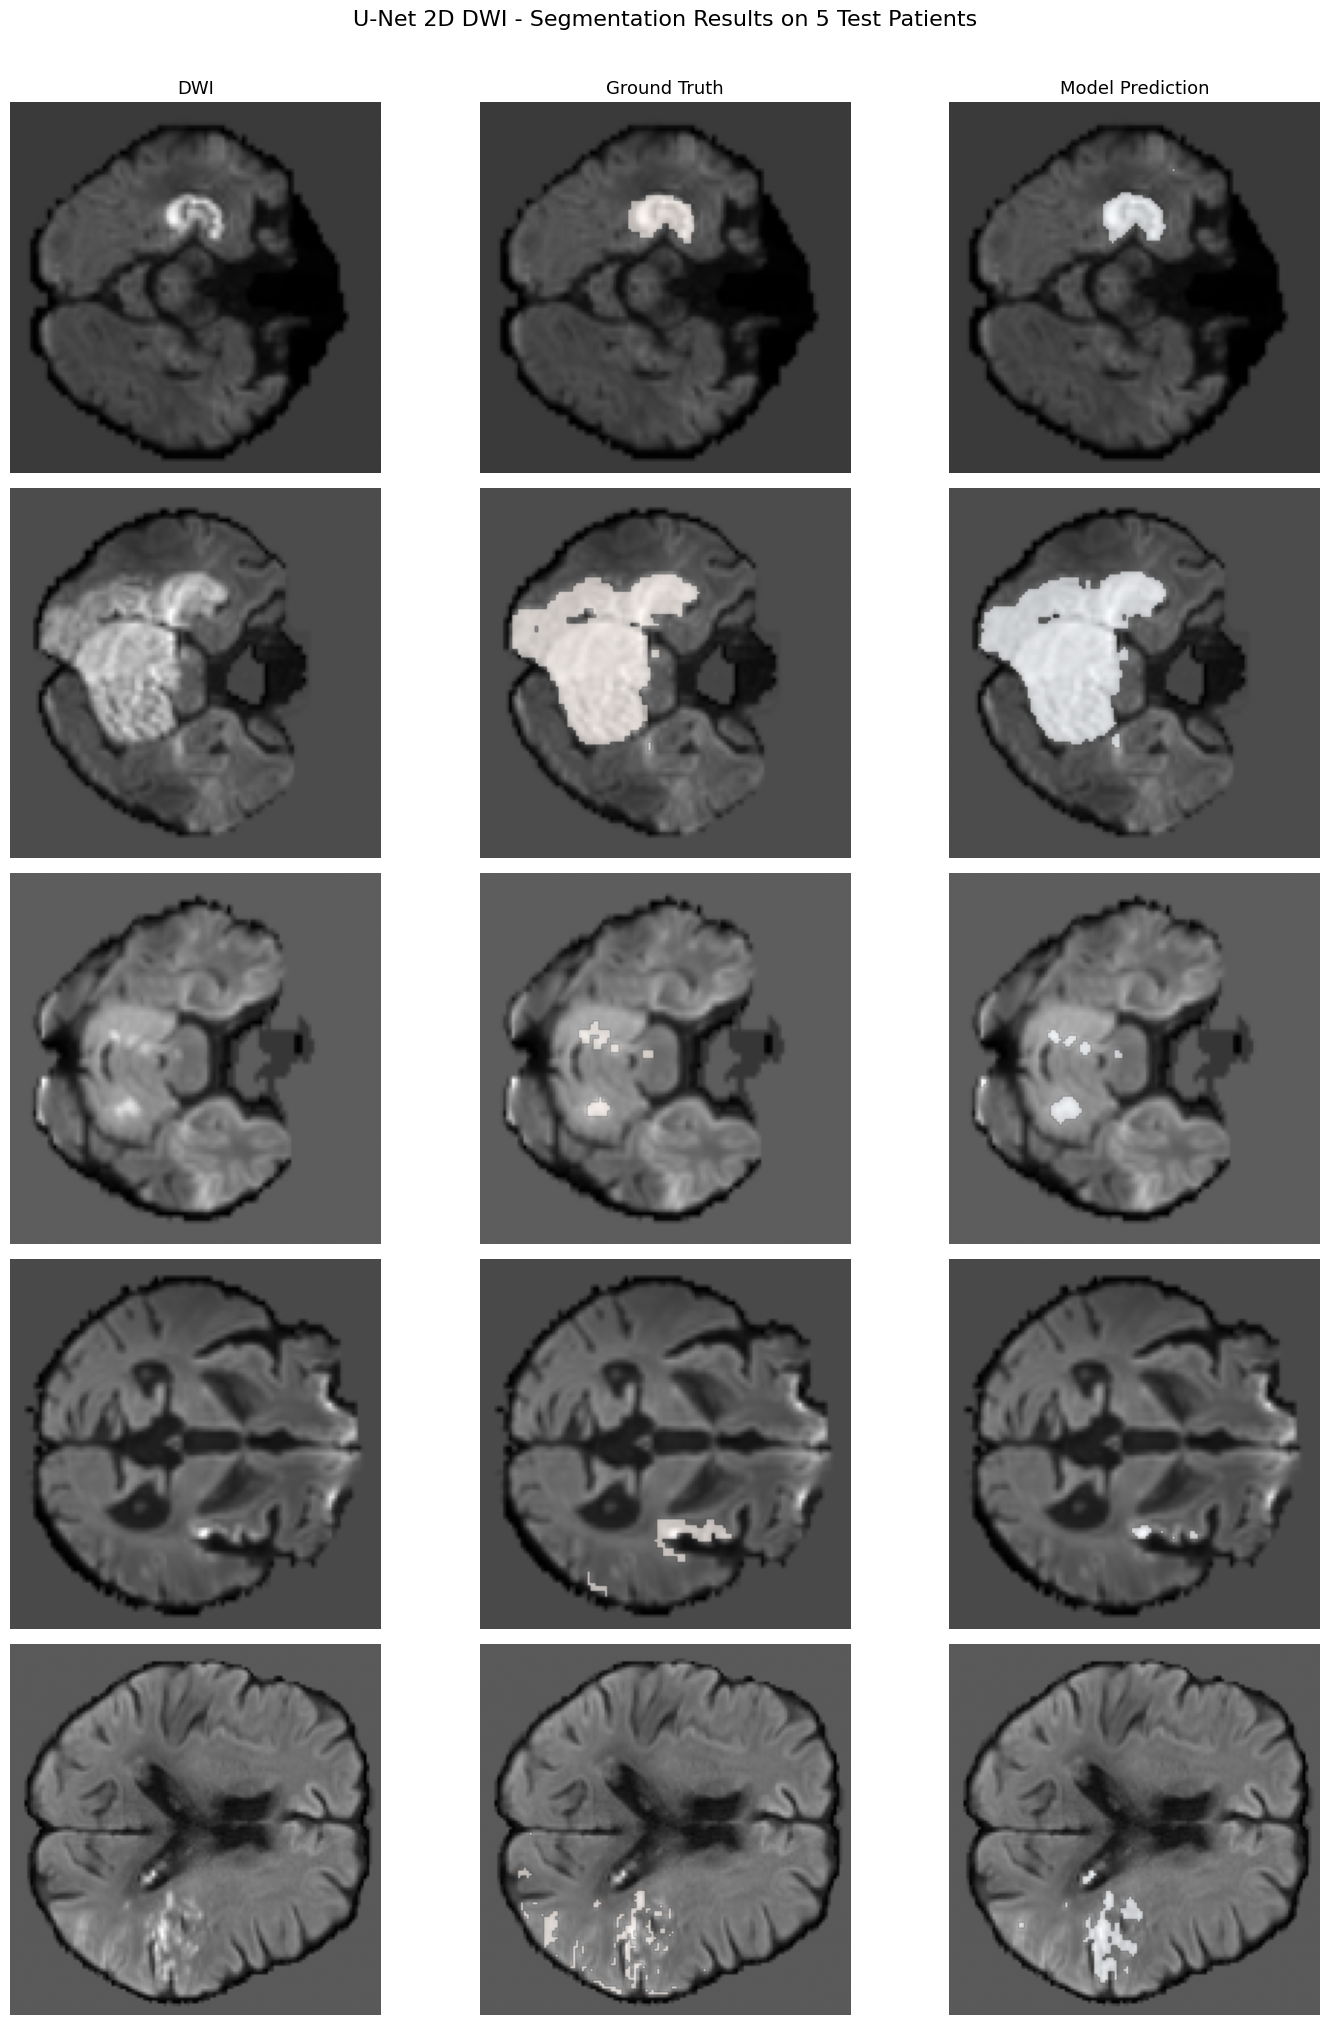

🏃 View run DWI_2D_Adam_lr5e4_DWI at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/883ef5b4a8674ef18c886dfcac6cb234
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
DWI segmentation visualization logged to the Best Run.


In [29]:
model.eval()
NUM_PATIENTS_TO_SHOW = 5
selected_patients = test_patients[:NUM_PATIENTS_TO_SHOW]
fig, axes = plt.subplots(NUM_PATIENTS_TO_SHOW, 3, figsize=(15, 4 * NUM_PATIENTS_TO_SHOW))
column_titles = ["DWI", "Ground Truth", "Model Prediction"]
for row, patient_dir in enumerate(selected_patients):
    dwi = np.load(patient_dir / "dwi.npy").astype(np.float32)
    mask = np.load(patient_dir / "mask.npy").astype(np.float32)
    lesion_per_slice = mask.sum(axis=(0, 1))
    slice_idx = np.argmax(lesion_per_slice)
    dwi_slice = dwi[:, :, slice_idx]
    gt = mask[:, :, slice_idx]
    mean = dwi_slice.mean()
    std = dwi_slice.std()
    dwi_normalized = (dwi_slice - mean) / std if std > 0 else dwi_slice.copy()
    image_tensor = torch.from_numpy(dwi_normalized).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(image_tensor)
        prediction = (torch.sigmoid(output) > 0.5).float().squeeze().cpu().numpy()
    axes[row, 0].imshow(dwi_slice, cmap="gray")
    axes[row, 1].imshow(dwi_slice, cmap="gray")
    axes[row, 1].imshow(np.ma.masked_where(gt == 0, gt), cmap="Reds", alpha=0.6)
    axes[row, 2].imshow(dwi_slice, cmap="gray")
    axes[row, 2].imshow(np.ma.masked_where(prediction == 0, prediction), cmap="Blues", alpha=0.6)
    patient_name = patient_dir.name
    axes[row, 0].set_ylabel(f"{patient_name}\nSlice {slice_idx}", fontsize=10)
    for col in range(3):
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(column_titles[col], fontsize=13)
plt.suptitle("U-Net 2D DWI - Segmentation Results on 5 Test Patients", fontsize=16, y=1.01)
plt.tight_layout()
prediction_dir = SAVE_DIR / "mlflow_predictions"
prediction_dir.mkdir(parents=True, exist_ok=True)
segmentation_visualization_path = prediction_dir / "segmentation_visualization.png"
plt.savefig(segmentation_visualization_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
with mlflow.start_run(run_id=best_result["MLflow Run ID"]):
    mlflow.log_artifact(str(segmentation_visualization_path), artifact_path="predictions")
print("DWI segmentation visualization logged to the Best Run.")

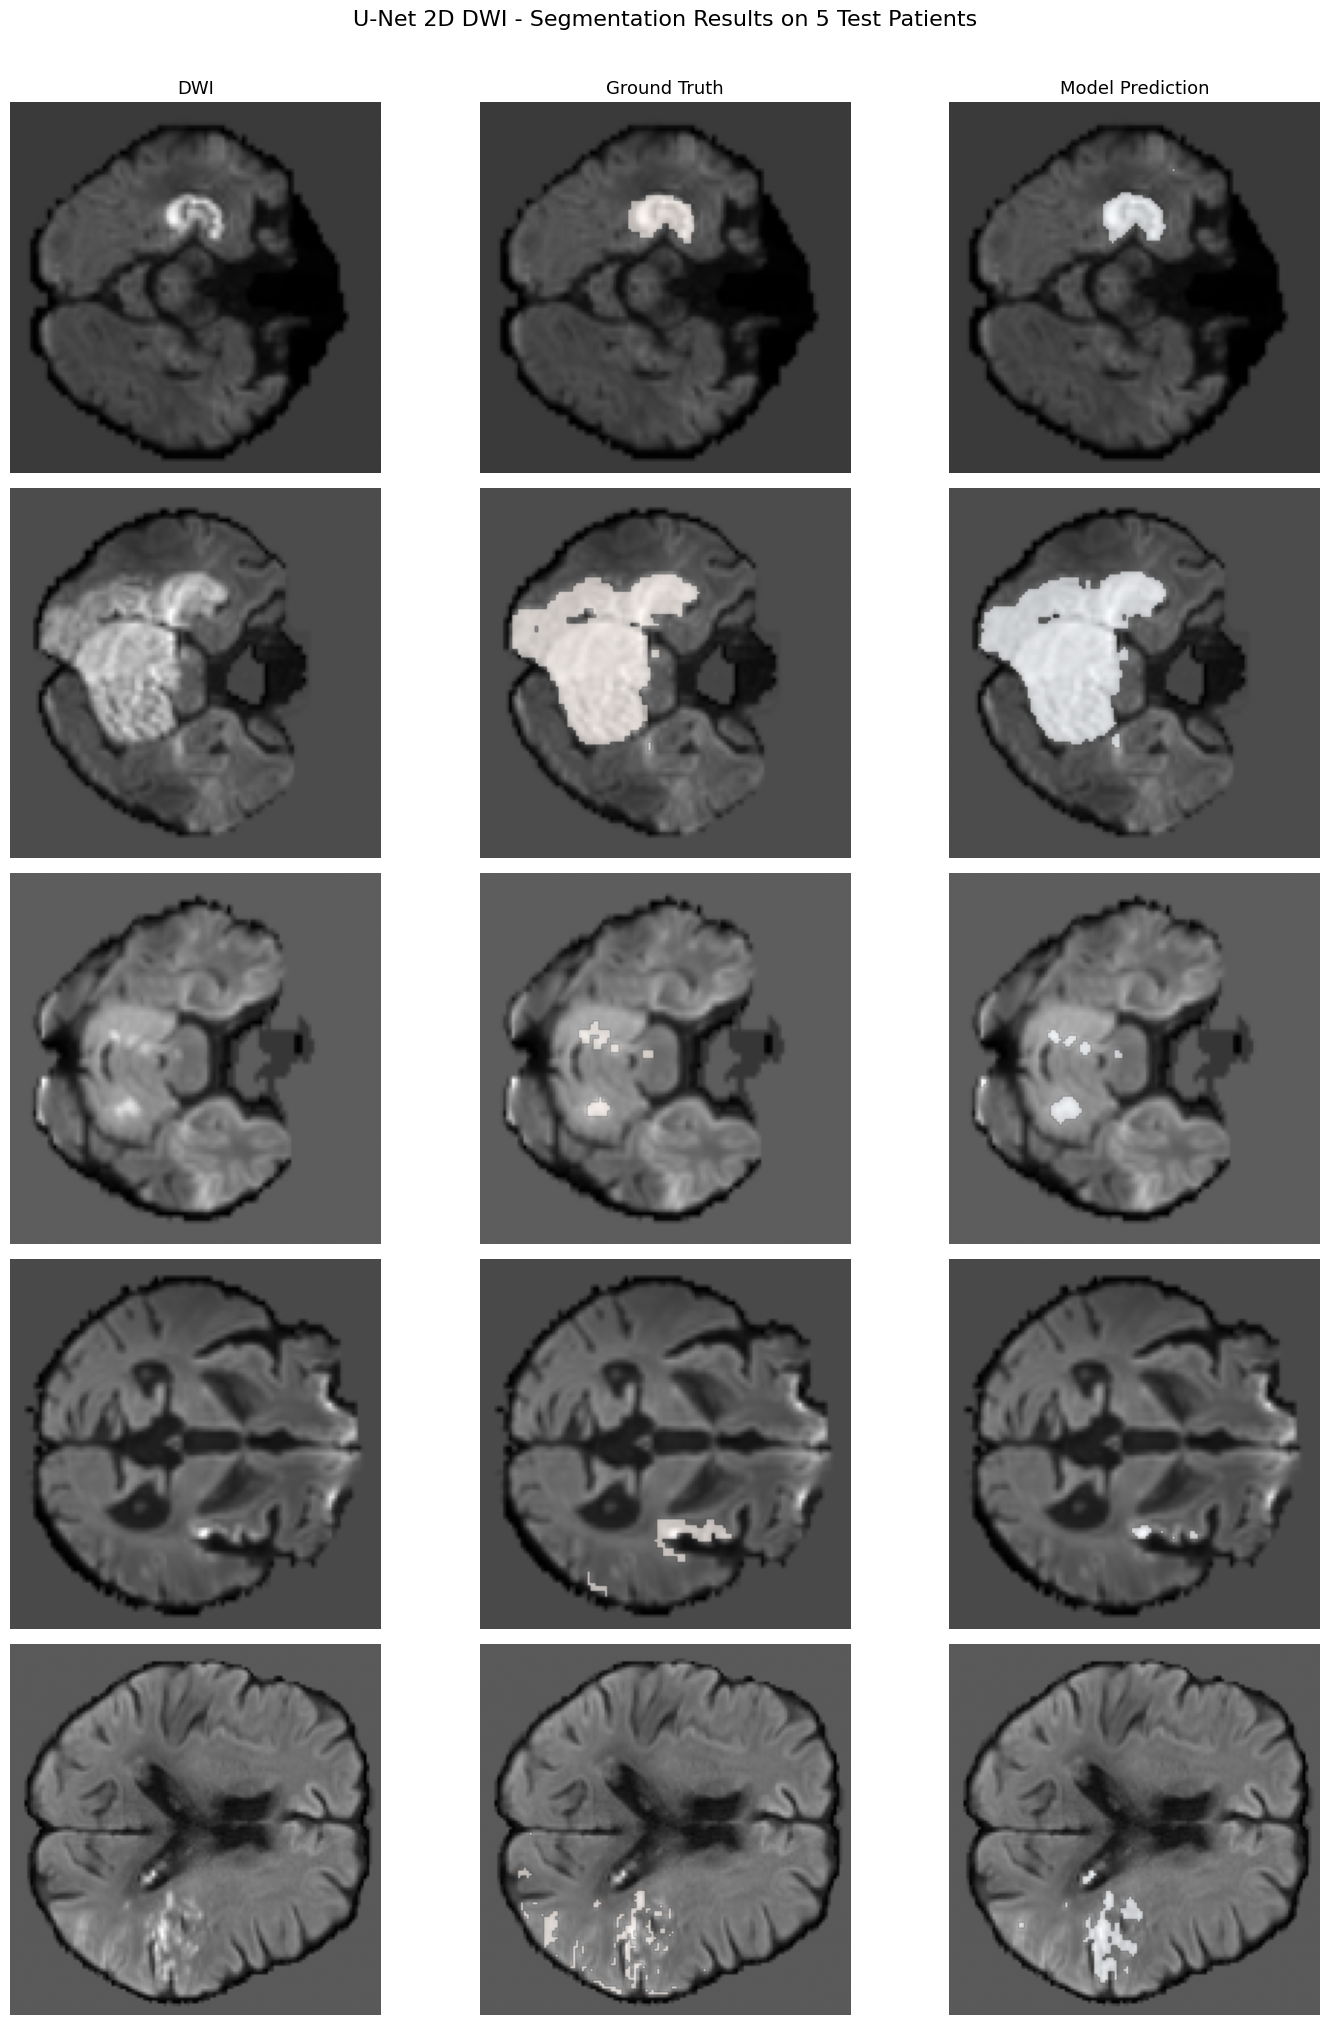

🏃 View run DWI_2D_Adam_lr5e4_DWI at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/883ef5b4a8674ef18c886dfcac6cb234
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
DWI segmentation visualization logged to the Best Run.


In [30]:
model.eval()
NUM_PATIENTS_TO_SHOW = 5
selected_patients = test_patients[:NUM_PATIENTS_TO_SHOW]
fig, axes = plt.subplots(NUM_PATIENTS_TO_SHOW, 3, figsize=(15, 4 * NUM_PATIENTS_TO_SHOW))
column_titles = ["DWI", "Ground Truth", "Model Prediction"]
for row, patient_dir in enumerate(selected_patients):
    dwi = np.load(patient_dir / "dwi.npy").astype(np.float32)
    mask = np.load(patient_dir / "mask.npy").astype(np.float32)
    lesion_per_slice = mask.sum(axis=(0, 1))
    slice_idx = np.argmax(lesion_per_slice)
    dwi_slice = dwi[:, :, slice_idx]
    gt = mask[:, :, slice_idx]
    mean = dwi_slice.mean()
    std = dwi_slice.std()
    dwi_normalized = (dwi_slice - mean) / std if std > 0 else dwi_slice.copy()
    image_tensor = torch.from_numpy(dwi_normalized).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(image_tensor)
        prediction = (torch.sigmoid(output) > 0.5).float().squeeze().cpu().numpy()
    axes[row, 0].imshow(dwi_slice, cmap="gray")
    axes[row, 1].imshow(dwi_slice, cmap="gray")
    axes[row, 1].imshow(np.ma.masked_where(gt == 0, gt), cmap="Reds", alpha=0.6)
    axes[row, 2].imshow(dwi_slice, cmap="gray")
    axes[row, 2].imshow(np.ma.masked_where(prediction == 0, prediction), cmap="Blues", alpha=0.6)
    patient_name = patient_dir.name
    axes[row, 0].set_ylabel(f"{patient_name}\nSlice {slice_idx}", fontsize=10)
    for col in range(3):
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(column_titles[col], fontsize=13)
plt.suptitle("U-Net 2D DWI - Segmentation Results on 5 Test Patients", fontsize=16, y=1.01)
plt.tight_layout()
prediction_dir = SAVE_DIR / "mlflow_predictions"
prediction_dir.mkdir(parents=True, exist_ok=True)
segmentation_visualization_path = prediction_dir / "segmentation_visualization.png"
plt.savefig(segmentation_visualization_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
with mlflow.start_run(run_id=best_result["MLflow Run ID"]):
    mlflow.log_artifact(str(segmentation_visualization_path), artifact_path="predictions")
print("DWI segmentation visualization logged to the Best Run.")